In [37]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from shapely.geometry import Point, LineString



In [32]:
waterways = gpd.read_file("/Users/jasperbosma/Desktop/data grachtenplanner/geojsons/Grachten.geojson")
stations = gpd.read_file("/Users/jasperbosma/Desktop/data grachtenplanner/geojsons/rondvaartopenafstapplekken.geojson")
gdf_lines = waterways.to_crs(epsg=28992)
gdf_points = stations.to_crs(epsg=28992)

In [8]:
bbox = (4.728, 52.278, 5.079, 52.431)
bbox_geom = box(*bbox)
waterways_subset = waterways[waterways.intersects(bbox_geom)]


In [38]:
G = nx.Graph()

for idx, row in gdf_lines.iterrows():
    geom = row.geometry

    if geom.geom_type == 'LineString':
        lines = [geom]
    elif geom.geom_type == 'MultiLineString':
        lines = list(geom.geoms)
    else:
        continue  # Skip unsupported types

    for line in lines:
        coords = list(line.coords)
        for i in range(len(coords) - 1):
            p1, p2 = coords[i], coords[i + 1]
            dist = Point(p1).distance(Point(p2))  # meters
            G.add_edge(p1, p2, weight=dist)

In [42]:
# def snap_point_to_graph(point: Point, graph_nodes):
#     return min(graph_nodes, key=lambda node: point.distance(Point(node)))

# snapped_nodes = [
#     snap_point_to_graph(pt, G.nodes)
#     for pt in gdf_points.geometry
# ]

In [40]:
start_geom = gdf_points.geometry.iloc[0]
end_geom = gdf_points.geometry.iloc[1]

start_node = snap_point_to_graph(start_geom, G.nodes)
end_node = snap_point_to_graph(end_geom, G.nodes)

In [43]:
def snap_point_to_graph(point: Point, graph_nodes):
    return min(graph_nodes, key=lambda node: point.distance(Point(node)))

snapped_nodes = [
    snap_point_to_graph(pt, G.nodes)
    for pt in gdf_points.geometry
]

# === STEP 4: Build Route by Connecting Points in Order ===
full_path_coords = []

for i in range(len(snapped_nodes) - 1):
    start = snapped_nodes[i]
    end = snapped_nodes[i + 1]

    try:
        segment_path = nx.shortest_path(G, source=start, target=end, weight='weight')
        if full_path_coords:
            # Avoid repeating last point
            segment_path = segment_path[1:]
        full_path_coords.extend(segment_path)
    except nx.NetworkXNoPath:
        print(f"❌ No path between point {i} and point {i+1}")

# === STEP 5: Create GeoDataFrame from Full Route ===
if full_path_coords:
    route_geom = LineString(full_path_coords)
    route_gdf = gpd.GeoDataFrame(geometry=[route_geom], crs=CRS_RDNEW)
    route_gdf.to_file(OUTPUT_ROUTE_FILE, driver="GeoJSON")
    print(f"✅ Multi-point route saved to: {OUTPUT_ROUTE_FILE}")

    # === STEP 6: Plot ===
    base = gdf_lines.plot(color="lightgray", figsize=(10, 10))
    gdf_points.plot(ax=base, color="blue", markersize=50)
    route_gdf.plot(ax=base, color="red", linewidth=3)
    plt.title("Multi-point Shortest Route")
    plt.axis('off')
    plt.show()
else:
    print("❌ No route was generated.")

❌ No path between point 34 and point 35
❌ No path between point 35 and point 36
❌ No path between point 120 and point 121
❌ No path between point 121 and point 122
❌ No path between point 137 and point 138
❌ No path between point 138 and point 139


NameError: name 'CRS_RDNEW' is not defined

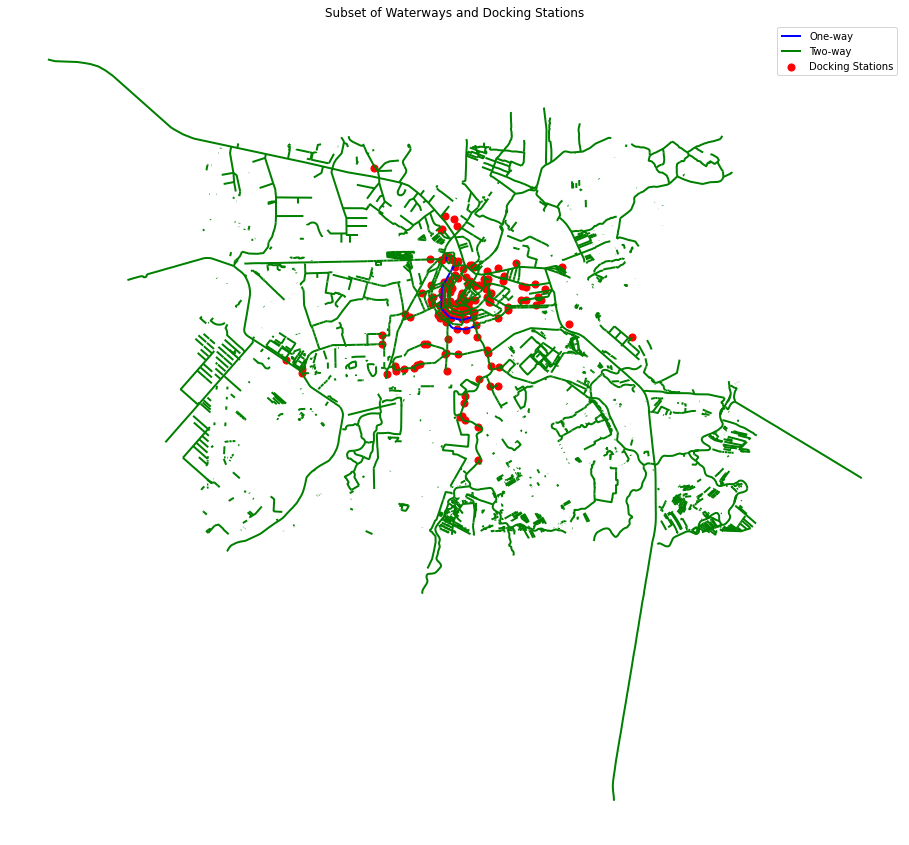

In [13]:
fig, ax = plt.subplots(figsize=(20, 15))

# One-way and two-way plots
waterways_subset[waterways_subset['oneway']].plot(ax=ax, color='blue', linewidth=2, label='One-way')
waterways_subset[~waterways_subset['oneway']].plot(ax=ax, color='green', linewidth=2, label='Two-way')

stations.plot(ax=ax, color='red', markersize=50, label='Docking Stations')

plt.title("Subset of Waterways and Docking Stations")
plt.axis('off')
plt.legend()
plt.show()

In [26]:
import networkx as nx
from shapely.geometry import LineString

# Create a directed graph
G = nx.DiGraph()

for _, row in waterways_subset.iterrows():
    line: LineString = row.geometry
    speed = row['speed_kmh']  # assuming 'speed' is the key

    # Break the line into start and end points
    coords = list(line.coords)
    for i in range(len(coords) - 1):
        start = coords[i]
        end = coords[i+1]

        segment_length = LineString([start, end]).length  # in meters
        travel_time = segment_length / speed  # assuming speed is in m/s

        G.add_edge(start, end, weight=travel_time, geometry=LineString([start, end]))


NotImplementedError: Multi-part geometries do not provide a coordinate sequence

In [27]:
from shapely.ops import nearest_points
import numpy as np

def closest_node(point, G):
    # Convert point to tuple
    x, y = point.x, point.y
    closest = min(G.nodes, key=lambda n: (n[0]-x)**2 + (n[1]-y)**2)
    return closest

stop_nodes = stops.geometry.apply(lambda p: closest_node(p, G))

NameError: name 'stops' is not defined

FileNotFoundError: [Errno 2] No such file or directory: 'Grachten.geojson'